In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import json
import os

os.chdir("../")
from scripts import utils, alerceanomalies
import matplotlib.gridspec as gridspec
from tqdm.auto import tqdm

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

from sklearn.svm import OneClassSVM
import distclassipy as dcpy
from distclassipy.anomaly import DistanceAnomaly
from sklearn.model_selection import train_test_split

from sklearn.base import BaseEstimator, OutlierMixin
epsilon = np.finfo(np.float32).eps
with open("settings.txt") as f:
    settings_dict = json.load(f)
seed_val = settings_dict["seed_choice"]
np.random.seed(seed_val)
sns_dict = settings_dict["sns_dict"]
sns.set_theme(**sns_dict)

from IPython.core.display import HTML
from IPython.display import display

import squarify
set3colors = [matplotlib.colors.rgb2hex(x) for x in plt.cm.Set3.colors]
knowncolors = set3colors[:4]
unknowncolors = ['#e6194B', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#42d4f4', '#f032e6', '#bfef45', '#fabed4', '#469990', '#dcbeff', '#9A6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#a9a9a9']
unknowncolors = set3colors[4:]+unknowncolors

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

In [2]:
# Create a dictionary of all models to test
models_to_test = {
    "DistClassiPy (min-median)": DistanceAnomaly(
        cluster_agg='min',
        metric_agg='median',
        normalize_scores=True
    ),
    
    "DistClassiPy (min-mean)": DistanceAnomaly(
        cluster_agg='min',
        metric_agg='mean',
        normalize_scores=True
    ),

    "IsolationForest": IsolationForest( #using alerce anomaly params
        n_estimators=100,
        max_samples=256,
        contamination=0.001,
        random_state=seed_val+2
    ),
    "LocalOutlierFactor": LocalOutlierFactor(
        n_neighbors=20, 
        novelty=True,  # IMPORTANT: Allows use on new data
        contamination='auto'
    ),
    
    "OneClassSVM": OneClassSVM(
        kernel='rbf',
        nu=0.001
    ),

    # "Autoencoder": alerceanomalies.AutoencoderAnomalyDetector(
    #     encoding_dim=32, # Can be tuned
    #     epochs=200,
    #     patience=10,
    # ),


    # "Variational Autoencoder": alerceanomalies.VAEAnomalyDetector(
    #     encoding_dim=32, # Can be tuned
    #     epochs=200,
    #     patience=10,
    #     loss_samples=5 # Number of samples for the reconstruction term in ELBO
    # ),

    # "DeepSVDD": alerceanomalies.DeepSVDDAnomalyDetector(
    #     encoding_dim=32, # Can be tuned
    #     epochs=200,
    #     patience=10,
    # ),

    # "ClassSVDD": alerceanomalies.ClassSVDDAnomalyDetector(
    #     z_dim=64,
    #     epochs=250,
    #     patience=15,
    #     lr=1e-4,
    #     verbose=False
    # )
}

In [3]:
traindat = pd.read_pickle("data/alercedata/train_data_filtered.pkl").set_index("oid")
testdat = pd.read_pickle("data/alercedata/test_data_filtered.pkl").set_index("oid")
feature_list = pd.read_pickle("data/alercedata/features_BHRF_model.pkl")

commondat = pd.concat([traindat,testdat])
commondat=commondat.rename(columns={"classALeRCE":"class"})

#### RESAMPLE
# commondat=commondat.groupby('class').apply(lambda x: x.sample(n=min(3000,len(x)), random_state=seed_val)).reset_index(drop=True) 

In [4]:
alerce_taxonomy = {
    "Transient": ["SLSN", "SNII", "SNIa", "SNIbc"],
    "Stochastic": ["QSO", "YSO", "AGN", "Blazar", "CV/Nova"],
    "Periodic": ["CEP",  "DSCT", "E", "RRL", "LPV"] 
}

features_to_use = [
    "SPM_A_1",
    "SPM_t0_1", 
    "SPM_gamma_1", 
    "SPM_beta_1", 
    "SPM_tau_rise_1", 
    "SPM_tau_fall_1", 
    "SPM_chi_1", 
    "SPM_A_2", 
    "SPM_t0_2", 
    "SPM_gamma_2", 
    "SPM_beta_2", 
    "SPM_tau_rise_2", 
    "SPM_tau_fall_2", 
    "SPM_chi_2"
]

In [6]:
results_log = []

for top_level_class, subclasses in alerce_taxonomy.items():
    print(f"--- Processing Top-Level Class: {top_level_class} ---")
    
    top_level_df = commondat[commondat['class'].isin(subclasses)]
    top_level_df = top_level_df.loc[:,features_to_use].dropna(subset=features_to_use)
    
    
    for anomaly_subclass in subclasses:
        print(f"  Treating '{anomaly_subclass}' as the anomaly...")

        inlier_df = top_level_df[top_level_df['class'] != anomaly_subclass]
        outlier_df = top_level_df[top_level_df['class'] == anomaly_subclass]

        if len(outlier_df) == 0:
            print(f"\tSkipping {anomaly_subclass}, no samples found.")
            continue

        # First split inliers into train/test
        inlier_train_df, inlier_test_df = train_test_split(
            inlier_df, test_size=0.2, random_state=seed_val,
            stratify=inlier_df['class'],
        )
        X_train = inlier_train_df[features_to_use].to_numpy()
        y_train = inlier_train_df['class'].to_numpy()

        # Add outliers to test only
        X_test_inliers = inlier_test_df[features_to_use].to_numpy()
        X_test_outliers = outlier_df[features_to_use].to_numpy()
        X_test = np.vstack([X_test_inliers, X_test_outliers])
        y_true = np.concatenate([
            np.zeros(len(X_test_inliers)),
            np.ones(len(X_test_outliers))
        ])

        # STD SCALER
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        for model_name, model in tqdm(models_to_test.items(), desc=f"Models for {anomaly_subclass}", leave=False):
            if "DistClassiPy" in model_name or "ClassSVDD" in model_name:
                model.fit(X_train_scaled, y_train)
            else:
                model.fit(X_train_scaled)
    
            y_scores = model.decision_function(X_test_scaled)
            
            # Flip scores where lower means more anomalous
            if model_name in ["IsolationForest", "LocalOutlierFactor", "OneClassSVM"]:
                y_scores = -y_scores
            
            # metrics
            auroc = roc_auc_score(y_true, y_scores)
            roc_curves = roc_curve(y_true, y_scores)
            
            results_log.append({
                "top_level_class": top_level_class,
                "anomaly_subclass": anomaly_subclass,
                "model": model_name,
                "auroc": auroc,
                "roc_curves": roc_curves,
            })

final_results_df = pd.DataFrame(results_log)

--- Processing Top-Level Class: Transient ---
  Treating 'SLSN' as the anomaly...


Models for SLSN:   0%|          | 0/5 [00:00<?, ?it/s]

  Treating 'SNII' as the anomaly...


Models for SNII:   0%|          | 0/5 [00:00<?, ?it/s]

  Treating 'SNIa' as the anomaly...


...

Models for E:   0%|          | 0/5 [00:00<?, ?it/s]

  Treating 'RRL' as the anomaly...


Models for RRL:   0%|          | 0/5 [00:00<?, ?it/s]

  Treating 'LPV' as the anomaly...


Models for LPV:   0%|          | 0/5 [00:00<?, ?it/s]

In [69]:
summary_table = final_results_df.pivot_table(
    index='model', 
    columns='anomaly_subclass', 
    values='auroc'
)

# Reorder columns to match the paper's structure for easier comparison
ordered_columns = [sc for tlc in alerce_taxonomy.values() for sc in tlc if sc in summary_table.columns]
summary_table = summary_table[ordered_columns]

print("\n" + "="*50)
print(" AUROC Comparison Summary (Higher is Better)")
print("="*50)
display(summary_table.style.format("{:.0%}").background_gradient(cmap='Greens', axis=0, vmin=0.5, vmax=1))


 AUROC Comparison Summary (Higher is Better)


anomaly_subclass,SLSN,SNII,SNIa,SNIbc,QSO,YSO,AGN,Blazar,CV/Nova,CEP,DSCT,E,RRL,LPV
model,,,,,,,,,,,,,,
DistClassiPy (min-mean),72%,74%,23%,59%,36%,79%,55%,59%,80%,55%,50%,48%,38%,58%
DistClassiPy (min-median),66%,75%,30%,59%,37%,81%,54%,55%,75%,54%,51%,48%,37%,59%
IsolationForest,81%,84%,44%,59%,36%,85%,60%,67%,95%,55%,52%,49%,47%,75%
LocalOutlierFactor,76%,86%,40%,64%,45%,68%,56%,59%,83%,50%,50%,50%,52%,80%
OneClassSVM,57%,68%,63%,57%,61%,39%,44%,42%,75%,37%,42%,53%,50%,70%


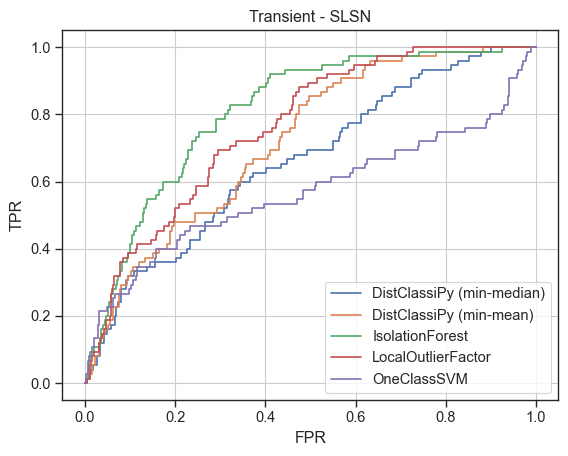

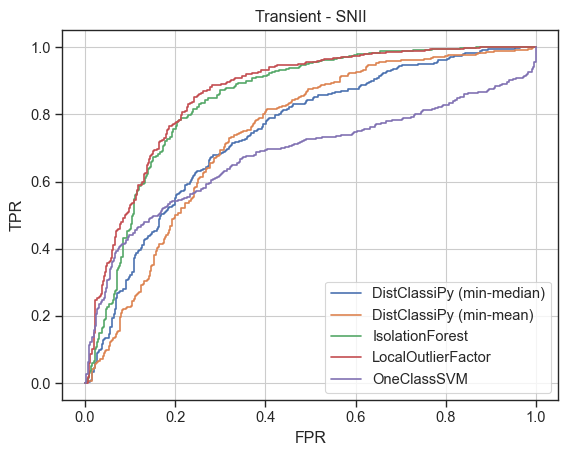

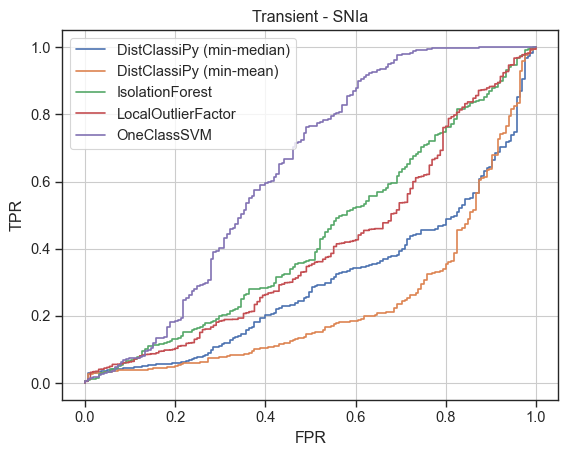

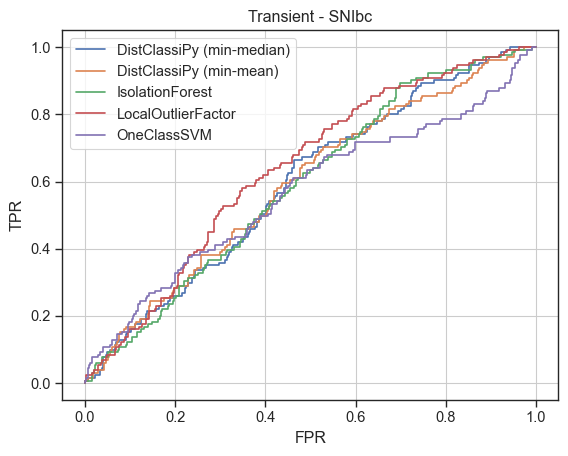

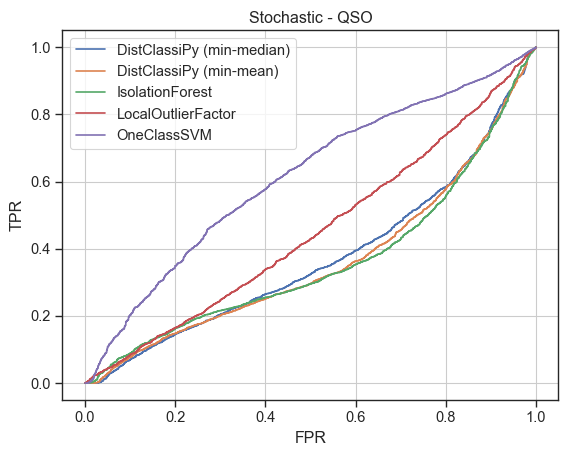

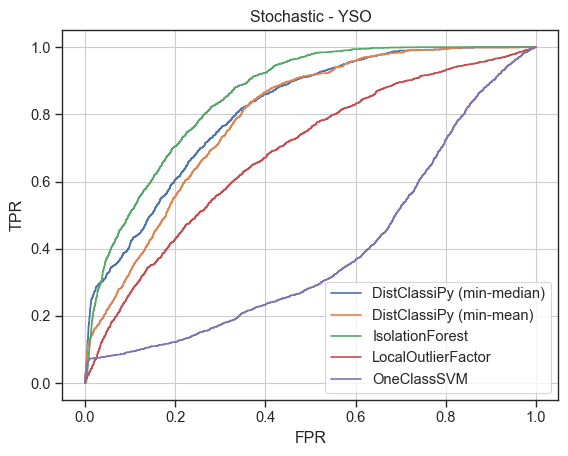

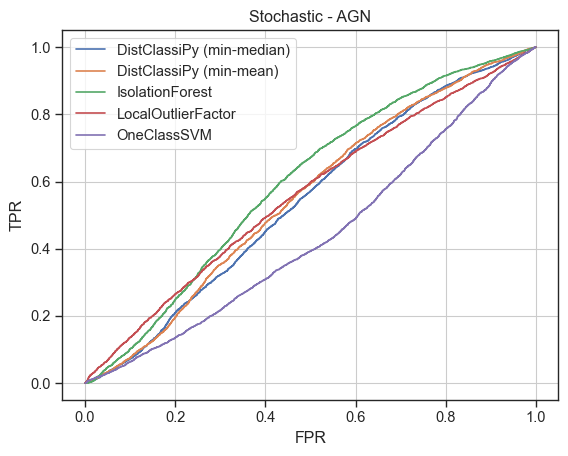

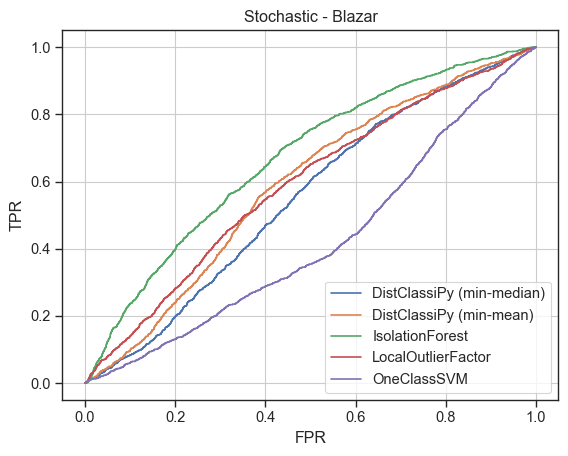

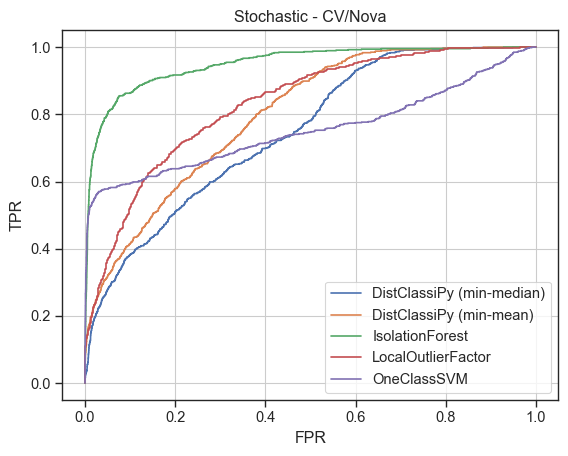

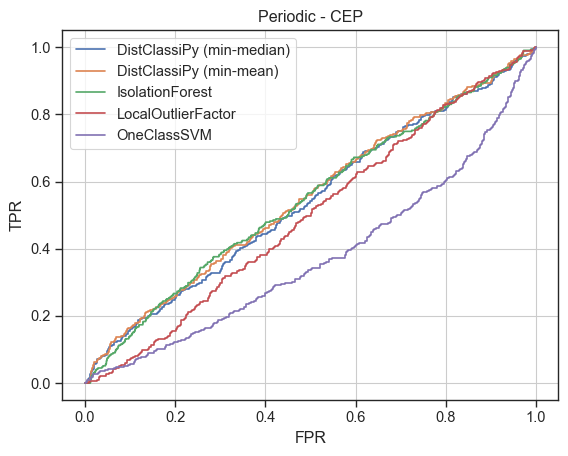

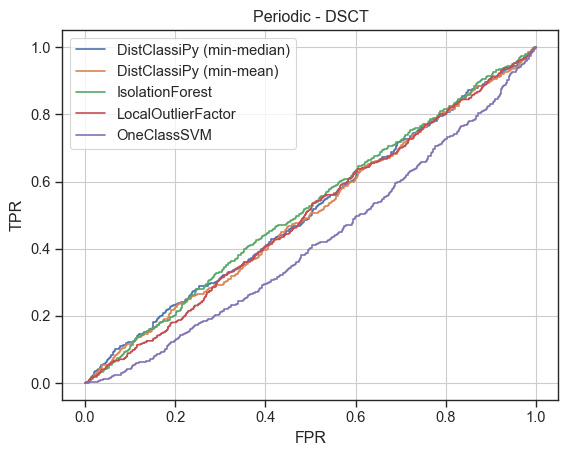

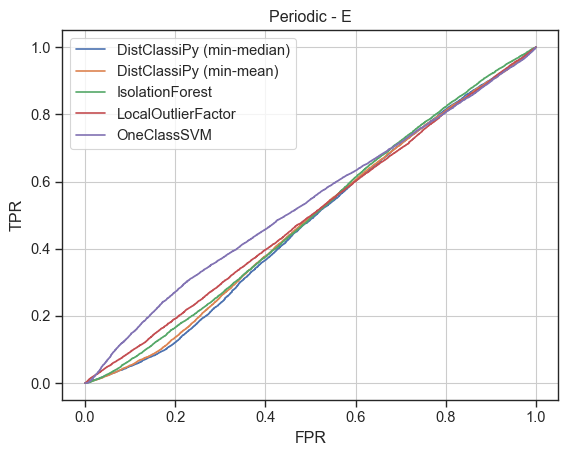

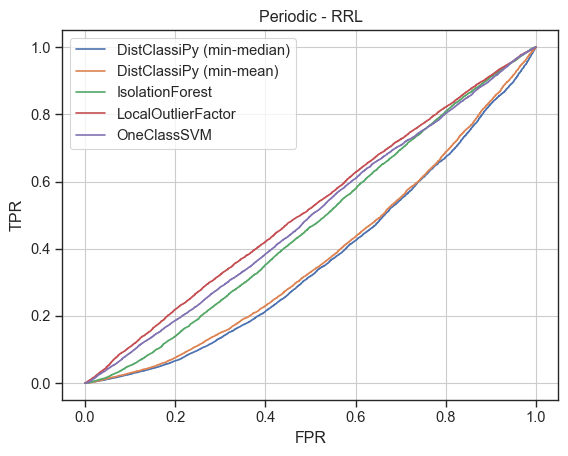

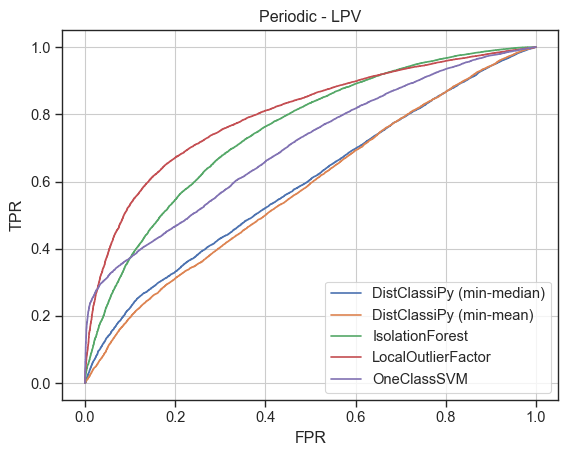

In [55]:
totexps = sum([len(alerce_taxonomy[x]) for x in alerce_taxonomy])

for itnum in range(1, totexps+1):
    start = (itnum - 1) * len(results_log)//totexps
    end   = itnum * len(results_log)//totexps
    cur_results = results_log[start:end]

    for result in cur_results:
        title = f"{result['top_level_class']} - {result['anomaly_subclass']}"
        fpr, tpr, thresholds = result["roc_curves"]
        plt.plot(fpr, tpr, label=result["model"])
    plt.title(title)
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.legend()
    plt.show()